In [ ]:
%%capture
try:
    import numpyro
except:
    !pip install numpyro
    import numpyro

!pip install funsor

try:
    from juliacall import Main as jl
except:
    !pip install juliacall
    from juliacall import Main as jl

In [ ]:
import numpy as np
import numpyro
import numpyro.distributions as dist
import numpyro.distributions.constraints as constraints
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO
import matplotlib.pyplot as plt
import scipy.stats as stats
import funsor
import pandas as pd
import seaborn as sns
import jax
import jax.numpy as jnp
import sys
import os
import time
import copy
import random
import arviz as az
from itertools import product
import scipy
import os
import pickle

numpyro.set_host_device_count(4)

DEBUG_PRINTS = True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base directory
BASE_DIR = '/content/drive/MyDrive/thesis-pomdp-inference/'
TIGER_DIR = f'{BASE_DIR}/tiger-pomdp/'

os.makedirs(TIGER_DIR, exist_ok=True)
os.makedirs(f'{TIGER_DIR}/inference/', exist_ok=True)
os.makedirs(f'{TIGER_DIR}/experiments/', exist_ok=True)

print(f"Tiger POMDP directory ready: {TIGER_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tiger POMDP directory ready: /content/drive/MyDrive/thesis-pomdp-inference//tiger-pomdp/


In [ ]:
def save_data(filename, data, subdir='', show_prints=True):
    """Save data to Drive with subdirectory support"""
    save_dir = f'{TIGER_DIR}{subdir}/'
    os.makedirs(save_dir, exist_ok=True)

    filepath = f'{save_dir}{filename}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)

    if show_prints:
        print(f"Saved: {filename}")

def load_data(filename, subdir='', show_prints=True):
    """Load data from Drive"""
    filepath = f'{TIGER_DIR}{subdir}/{filename}.pkl'
    if os.path.exists(filepath):
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        if show_prints:
            print(f"Loaded: {filename}")
        return data
    else:
        if show_prints:
            print(f"Not found: {filename}")
        return None

def file_exists(filename, subdir='', show_prints=True):
    """Check if file exists"""
    filepath = f'{TIGER_DIR}{subdir}/{filename}.pkl'
    file_exists = os.path.exists(filepath)
    if show_prints:
        if file_exists:
            print(f"{filename} exists")
        else:
            print(f"{filename} does not exist")
    return file_exists

# Tiger POMDP (Partially Observable Markov Decision Process)

The Tiger POMDP is a classical problem in the field of artificial intelligence and decision-making under uncertainty. It's used to illustrate the challenges of decision-making when there's uncertainty about the state of the environment.

In the Tiger POMDP scenario, an agent is placed in a room with two doors. Behind one door is his freedom, and behind the other is a tiger. The agent doesn't know which door leads to which outcome. It can take actions like "listen" to hear a sound indicating the location of the tiger or "open" a door to reveal its contents. However, actions are imperfect, leading to uncertainty.

Solving the Tiger POMDP involves finding a policy that maximizes the expected cumulative reward over time, taking into account the uncertainty and partial observability. Various algorithms, such as belief state planning or particle filtering, can be used to approximate or solve POMDPs.

The Tiger POMDP can be represented as a Partially Observable Markov Decision Process (POMDP) defined by the tuple $(S, A, T, R, Ω, O, γ)$, where:

\\
$S$: The finite set of states consists of two elements representing the locations of the tiger and his freedom.

$A$: The finite set of actions available to the agent includes "listen" and "open" representing actions to gather information or make decisions.

$T$: The state transition function $T: S \times A \mapsto S$ describes the transition probabilities between states based on actions. For example, if the agent decides to "open" a door, the state transition function will determine the probabilities of transitioning to either the tiger or freedom state.

$R$: The reward function $R: S \times A \mapsto \mathbb{R}$ provides immediate rewards for actions in specific states. For instance, opening the door containing his freedom could yield a positive reward, while opening the door with the tiger will result in a negative reward.

$Ω$: The finite set of observations consists of two elements representing the possible observations of "tiger-left" and "tiger-right" when the agent chooses to "listen".

$O$: The set of conditional observation probabilities $Ω$ specifies the likelihood of observing each possible observation given the true state of the environment.

$γ$: The discount factor $γ \in [0,1]$ accounts for the importance of future rewards relative to immediate rewards in the agent's decision-making process.

## Generating "Synthetic" Observations.

Now let's create synthetic observations / data for our model to learn from.

This synthetic data is following the rules of the original Tiger POMDP problem,
where the probability of getting a correct observation when doing "listen" action is 0.85.

Our observations will be in the form of a list that consists of episodes:

$b_{0},(a_{0},o_{0}),(a_{1},o_{1}),...,(,a_{n},o_{n})$

Where $(a_{t},o_{t})$ -

$a_{t}$ - the action taken in time step $t$

$o_{t}$ - the observation recieved at time step $t$

$\Omega = \{o_{tl}, o_{tr}\} $

Where $O(s',a,o) = P(o_{tl}|s',a_{listen}) = P(o_{tr}|s',a_{listen}) =
\begin{align}
     \left\{
        \begin{array}{cl}
        0.85 & \text{if s' == s}  \\
        0.15 & \text{if s' != s}
        \end{array}
    \right.
\end{align}$

\

$O(s'_{tl},a_{listen},o_{tl}) = 0.85$

$O(s'_{tl},a_{listen},o_{tr}) = 0.15$

$O(s'_{tr},a_{listen},o_{tl}) = 0.15$

$O(s'_{tr},a_{listen},o_{tr}) = 0.85$


The context here of s' is that I have "reached" the state that the action took me to.
Meaning - for example, we know that $a_{listen}$ keeps us in the same state, so if the real tiger location is behind the left door - acting $a_{listen}$ will result in s' = "tiger-left", and the probability of observing $o_{tl}$ is 0.85, and the probability of observing $o_{tr}$ is 0.15.

* When action $a$ is "open-left" or "open-right", then recieving $o_{tl}$ and $o_{tr}$ are evenly distributed (uniformly).

Explanation - Observing the correct state occurs with probability 0.85, for example when the state is $s_{tl}$ (meaning the tiger is behind the left door), we will recieve the correct observation - $o_{tl}$ (that the tiger is behind the left door) with probability 0.85, and we will recieve the incorrect observation - $o_{tr}$ with probability 0.15.

In [ ]:
Actions = ["listen", "open-left", "open-right"]
States = ["tiger-left", "tiger-right"]
Observations = ["tiger-left", "tiger-right"]
Inital_Belief_State = {"tiger-left": 0.5, "tiger-right": 0.5}
Terminate_Actions = ["open-left", "open-right"]

# Observation Model: {(state', action): {observation1: probability1, observation2: probability2}}
Observation_Model = {("tiger-left","listen"): {"tiger-left": 0.85,
                                               "tiger-right": 0.15},
                     ("tiger-right","listen"): {"tiger-left": 0.15,
                                                "tiger-right":0.85},
                     ("tiger-left","open-left"): {"tiger-right":0.5,
                                                   "tiger-left":0.5},
                     ("tiger-right","open-left"): {"tiger-right":0.5,
                                                   "tiger-left":0.5},
                     ("tiger-left","open-right"): {"tiger-right":0.5,
                                                   "tiger-left":0.5},
                     ("tiger-right","open-right"): {"tiger-right":0.5,
                                                   "tiger-left":0.5}}

# Transition Model: {(state, action): {state'1: probability1, state'2: probability2}}
Transition_Model = {("tiger-left","listen"): {"tiger-left": 1.0,
                                               "tiger-right": 0.0},
                     ("tiger-right","listen"): {"tiger-left": 0.0,
                                                "tiger-right":1.0},
                     ("tiger-left","open-left"): {"tiger-right":0.5,
                                                   "tiger-left":0.5},
                     ("tiger-right","open-left"): {"tiger-right":0.5,
                                                   "tiger-left":0.5},
                     ("tiger-left","open-right"): {"tiger-right":0.5,
                                                   "tiger-left":0.5},
                     ("tiger-right","open-right"): {"tiger-right":0.5,
                                                   "tiger-left":0.5}}

In [ ]:
# Install required Julia packages
jl.Pkg.add('POMDPs')
jl.Pkg.add('POMDPModels')
jl.Pkg.add('QMDP')
jl.Pkg.add('POMDPTools')

print("Julia packages installed successfully!")

Julia packages installed successfully!


In [ ]:
def create_tiger_pomdp(listening_accuracy=0.85, random_seed=123):
    """
    Create Tiger POMDP with specified listening accuracy

    Args:
        listening_accuracy: Probability of hearing tiger on correct side (0.5 = random, 1.0 = perfect)
        random_seed: Random seed for reproducibility
    """
    if DEBUG_PRINTS:
        print(f"Creating Tiger POMDP with listening_accuracy={listening_accuracy}...")

    try:
        jl.seval(f"""
        using POMDPs, POMDPModels, Random

        # Set random seed
        Random.seed!({random_seed})

        # Create Tiger POMDP with custom listening accuracy
        # Constructor: TigerPOMDP(r_listen, r_findtiger, r_escapetiger, p_listen_correctly, discount_factor)
        pomdp_env = TigerPOMDP(-1.0, -100.0, 10.0, {listening_accuracy}, 0.95)
        """)

        if DEBUG_PRINTS:
            print(f"Tiger POMDP created successfully!")
            print(f"  States: Tiger-Left (false→0), Tiger-Right (true→1)")
            print(f"  Actions: Listen (0), Open-Left (1), Open-Right (2)")
            print(f"  Observations: Hear-Left (false→0), Hear-Right (true→1)")
            print(f"  Listen cost: -1.0")
            print(f"  Find tiger penalty: -100.0")
            print(f"  Escape tiger reward: 10.0")
            print(f"  Listening accuracy: {listening_accuracy}")
            print(f"  Discount factor: 0.95")

        return jl.pomdp_env

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Tiger POMDP creation failed: {e}")
        return None

In [ ]:
def generate_policy(pomdp):
    """Generate a QMDP policy for given Tiger POMDP"""
    if DEBUG_PRINTS:
        print("Generating QMDP policy...")

    try:
        jl.training_pomdp = pomdp

        jl.seval(f"""
        using POMDPs, QMDP

        # Solve with QMDP on the provided POMDP
        solver = QMDPSolver(verbose=false)
        policy = solve(solver, training_pomdp)
        """)

        if DEBUG_PRINTS:
            print("QMDP policy generated successfully!")

        return jl.policy

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Policy generation failed: {e}")
        return None

In [ ]:
def test_tiger_policy(policy, true_pomdp, belief_pomdp=None, n_episodes=100, max_steps=50, random_seed=1000):
    """
    Test a policy on true Tiger environment with belief updates

    Args:
        policy: The policy to test
        true_pomdp: The TRUE environment to test in
        belief_pomdp: The POMDP model used for belief updates (if None, uses true environment)
        n_episodes: Number of episodes
        max_steps: Max steps per episode
        random_seed: Base random seed
    """
    if DEBUG_PRINTS:
        print(f"Testing policy for {n_episodes} episodes...")

    try:
        jl.test_policy = policy
        jl.true_env_pomdp = true_pomdp
        jl.belief_pomdp = belief_pomdp if belief_pomdp is not None else true_pomdp
        jl.n_eps = n_episodes
        jl.max_steps = max_steps
        jl.base_seed = random_seed

        jl.seval(f"""
        using POMDPs, POMDPTools, Statistics, Random

        episode_rewards = Float64[]
        all_trajectories = []

        # Use exact belief updates for Tiger POMDP (much simpler than particle filter)
        updater = DiscreteUpdater(belief_pomdp)

        for ep in 1:n_eps
            # Set different seed for each episode
            episode_seed = base_seed + ep - 1
            Random.seed!(episode_seed)

            # Initialize from TRUE environment
            s = rand(initialstate(true_env_pomdp))

            # Initialize belief using the belief model
            b0 = initialstate(belief_pomdp)
            b = initialize_belief(updater, b0)

            episode_reward = 0.0
            step = 0

            traj_states = []
            traj_actions = []
            traj_observations = []
            traj_rewards = []

            while !isterminal(true_env_pomdp, s) && step < max_steps
                # Get action based on (potentially wrong) beliefs
                a = action(test_policy, b)

                # Generate observation from TRUE environment
                sp, o, r = @gen(:sp, :o, :r)(true_env_pomdp, s, a)

                # Update belief using the belief model
                try
                    b = update(updater, b, a, o)
                catch e
                    # If update fails, keep previous belief
                end

                push!(traj_states, s)
                push!(traj_actions, a)
                push!(traj_observations, o)
                push!(traj_rewards, r)

                episode_reward += r
                s = sp
                step += 1
            end

            push!(episode_rewards, episode_reward)
            push!(all_trajectories, Dict(
                "states" => traj_states,
                "actions" => traj_actions,
                "observations" => traj_observations,
                "rewards" => traj_rewards
            ))
        end
        """)

        return jl.all_trajectories

    except Exception as e:
        if DEBUG_PRINTS:
            print(f"Policy testing failed: {e}")
        return None

In [ ]:
# Tiger POMDP parameters
N_EPISODES = 2000
MAX_STEPS = 10
RANDOM_SEED = 42
WRONG_LISTENING = 0.7
TRUE_LISTENING = 0.85

print("\n---- Creating Tiger POMDP environments... ----")

needs_regeneration = True
if file_exists('tiger_wrong_trajectories', subdir='data') and file_exists('tiger_true_trajectories', subdir='data'):
    wrong_trajectories = load_data('tiger_wrong_trajectories', subdir='data')
    true_trajectories = load_data('tiger_true_trajectories', subdir='data')

    if (wrong_trajectories and true_trajectories and
        wrong_trajectories.get('n_episodes') == N_EPISODES and
        wrong_trajectories.get('random_seed') == RANDOM_SEED and
        wrong_trajectories.get('wrong_listening') == WRONG_LISTENING and
        wrong_trajectories.get('true_listening') == TRUE_LISTENING):
        needs_regeneration = False
        print("Loaded existing Tiger trajectories")

if needs_regeneration:
    print("Generating new Tiger trajectories...")

    wrong_pomdp = create_tiger_pomdp(listening_accuracy=WRONG_LISTENING, random_seed=123)
    true_pomdp = create_tiger_pomdp(listening_accuracy=TRUE_LISTENING, random_seed=123)

    print("\n---- Generating policies... ----")
    wrong_policy = generate_policy(wrong_pomdp)
    true_policy = generate_policy(true_pomdp)

    print("\n---- Testing policies on TRUE environment... ----")
    print("Testing policy trained on WRONG model (0.7 accuracy)...")
    wrong_traj_julia = test_tiger_policy(
        wrong_policy,
        true_pomdp=true_pomdp,
        belief_pomdp=wrong_pomdp,
        n_episodes=N_EPISODES,
        max_steps=MAX_STEPS,
        random_seed=RANDOM_SEED
    )

    print("Testing policy trained on TRUE model (0.85 accuracy)...")
    true_traj_julia = test_tiger_policy(
        true_policy,
        true_pomdp=true_pomdp,
        belief_pomdp=true_pomdp,
        n_episodes=N_EPISODES,
        max_steps=MAX_STEPS,
        random_seed=RANDOM_SEED
    )

    # Convert Julia trajectories to Python format
    wrong_traj_list = [dict(traj) for traj in wrong_traj_julia]
    true_traj_list = [dict(traj) for traj in true_traj_julia]

    def julia_to_python_tiger(traj_dict):
        """Convert Tiger POMDP Julia trajectory to Python-native types"""
        return {
            'states': [int(s) for s in traj_dict['states']],
            'actions': [int(a) for a in traj_dict['actions']],
            'observations': [int(o) for o in traj_dict['observations']],
            'rewards': [float(r) for r in traj_dict['rewards']]
        }

    wrong_traj_python = [julia_to_python_tiger(t) for t in wrong_traj_list]
    true_traj_python = [julia_to_python_tiger(t) for t in true_traj_list]

    wrong_trajectories = {
        'trajectories': wrong_traj_python,
        'n_episodes': N_EPISODES,
        'max_steps': MAX_STEPS,
        'random_seed': RANDOM_SEED,
        'wrong_listening': WRONG_LISTENING,
        'true_listening': TRUE_LISTENING
    }

    true_trajectories = {
        'trajectories': true_traj_python,
        'n_episodes': N_EPISODES,
        'max_steps': MAX_STEPS,
        'random_seed': RANDOM_SEED,
        'listening_accuracy': TRUE_LISTENING
    }

    save_data('tiger_wrong_trajectories', wrong_trajectories, subdir='data')
    save_data('tiger_true_trajectories', true_trajectories, subdir='data')

print(f"Wrong policy trajectories: {len(wrong_trajectories['trajectories'])} episodes")
print(f"True policy trajectories: {len(true_trajectories['trajectories'])} episodes")


---- Creating Tiger POMDP environments... ----
tiger_wrong_trajectories does not exist
Generating new Tiger trajectories...
Creating Tiger POMDP with listening_accuracy=0.7...
Tiger POMDP created successfully!
  States: Tiger-Left (false→0), Tiger-Right (true→1)
  Actions: Listen (0), Open-Left (1), Open-Right (2)
  Observations: Hear-Left (false→0), Hear-Right (true→1)
  Listen cost: -1.0
  Find tiger penalty: -100.0
  Escape tiger reward: 10.0
  Listening accuracy: 0.7
  Discount factor: 0.95
Creating Tiger POMDP with listening_accuracy=0.85...
Tiger POMDP created successfully!
  States: Tiger-Left (false→0), Tiger-Right (true→1)
  Actions: Listen (0), Open-Left (1), Open-Right (2)
  Observations: Hear-Left (false→0), Hear-Right (true→1)
  Listen cost: -1.0
  Find tiger penalty: -100.0
  Escape tiger reward: 10.0
  Listening accuracy: 0.85
  Discount factor: 0.95

---- Generating policies... ----
Generating QMDP policy...
QMDP policy generated successfully!
Generating QMDP policy...

/tmp/ipython-input-3629144180.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=labels, patch_artist=True,


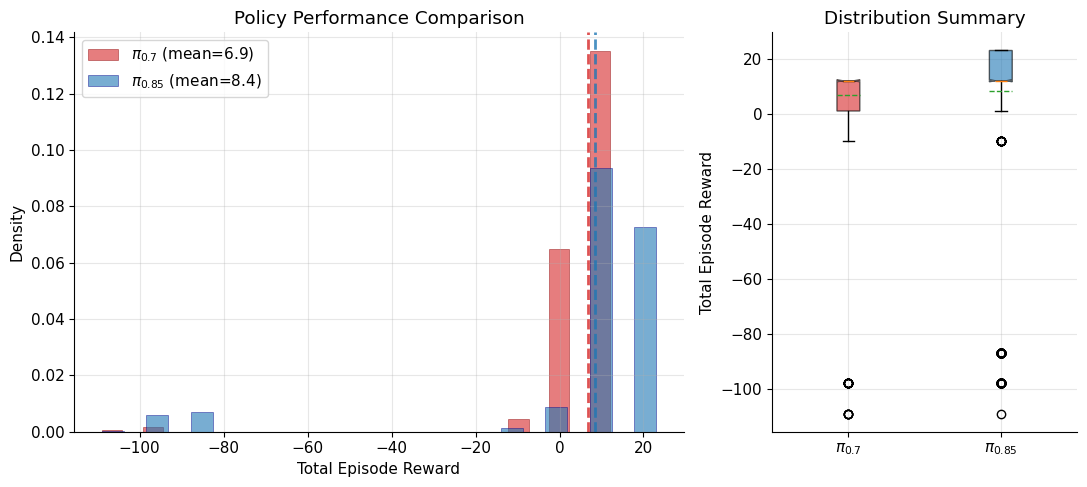

POLICY EVALUATION RESULTS
Episodes per policy: 2,000

Policy 0.7:
  Mean reward: 6.87 ± 12.49
  Median reward: 12.00

Policy 0.85:
  Mean reward: 8.44 ± 28.04
  Median reward: 12.00

Performance Gap:
  Difference: 1.56 (+22.7%)


In [ ]:
sim_rewards = [sum(ep['rewards']) for ep in wrong_trajectories['trajectories'] if ep is not None]
real_rewards = [sum(ep['rewards']) for ep in true_trajectories['trajectories'] if ep is not None]

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={'width_ratios': [2.0, 1.0]})

sim_rewards_np = np.array(sim_rewards)
real_rewards_np = np.array(real_rewards)
sim_mean, sim_std = np.mean(sim_rewards_np), np.std(sim_rewards_np)
real_mean, real_std = np.mean(real_rewards_np), np.std(real_rewards_np)

# Left plot
ax1.hist(sim_rewards_np, bins=25, alpha=0.6, density=True,
         label=rf'$\pi_{{0.7}}$ (mean={sim_mean:.1f})',
         color='#d62728', edgecolor='darkred', linewidth=0.5)
ax1.hist(real_rewards_np, bins=25, alpha=0.6, density=True,
         label=rf'$\pi_{{0.85}}$ (mean={real_mean:.1f})',
         color='#1f77b4', edgecolor='darkblue', linewidth=0.5)

ax1.axvline(sim_mean, color='#d62728', linewidth=2, linestyle='--', alpha=0.8)
ax1.axvline(real_mean, color='#1f77b4', linewidth=2, linestyle='--', alpha=0.8)

ax1.set_xlabel('Total Episode Reward')
ax1.set_ylabel('Density')
ax1.set_title('Policy Performance Comparison')
ax1.legend(loc='best')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right plot
box_data = [sim_rewards_np, real_rewards_np]
labels = [r'$\pi_{0.7}$', r'$\pi_{0.85}$']

bp = ax2.boxplot(box_data, labels=labels, patch_artist=True,
                 notch=True, showmeans=True, meanline=True)

bp['boxes'][0].set_facecolor('#d62728')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#1f77b4')
bp['boxes'][1].set_alpha(0.6)

ax2.set_ylabel('Total Episode Reward')
ax2.set_title('Distribution Summary')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("=" * 50)
print("POLICY EVALUATION RESULTS")
print("=" * 50)
print(f"Episodes per policy: {len(sim_rewards_np):,}")
print(f"\nPolicy 0.7:")
print(f"  Mean reward: {sim_mean:.2f} ± {sim_std:.2f}")
print(f"  Median reward: {np.median(sim_rewards_np):.2f}")
print(f"\nPolicy 0.85:")
print(f"  Mean reward: {real_mean:.2f} ± {real_std:.2f}")
print(f"  Median reward: {np.median(real_rewards_np):.2f}")
print(f"\nPerformance Gap:")
print(f"  Difference: {real_mean - sim_mean:.2f} ({((real_mean - sim_mean)/abs(sim_mean)*100):+.1f}%)")
print("=" * 50)

In [ ]:
def extract_tiger_trajectories(trajectories, n_episodes=None):
    if n_episodes is not None:
        trajectories = trajectories[:n_episodes]

    episodes = []

    for traj_idx, traj in enumerate(trajectories):
        traj_dict = dict(traj)

        states = traj_dict['states']
        actions = traj_dict['actions']
        observations = traj_dict['observations']
        rewards = traj_dict['rewards']

        # Find first door opening action
        first_open_idx = None
        for i, action in enumerate(actions):
            if int(action) in [1, 2]:
                first_open_idx = i
                break

        if first_open_idx is None:
            continue

        # Truncate episode at door opening
        episode_data = {
            'states': [int(s) for s in states[:first_open_idx+1]],
            'actions': [int(a) for a in actions[:first_open_idx+1]],
            'observations': [int(o) for o in observations[:first_open_idx]],  # exclude door obs
            'rewards': [float(r) for r in rewards[:first_open_idx+1]]
        }

        # Add treasure outcome as final observation
        final_reward = rewards[first_open_idx]
        treasure_outcome = 1 if final_reward > 0 else 0  # 1=treasure, 0=eaten
        episode_data['observations'].append(treasure_outcome)

        episodes.append(episode_data)

    inference_data = {
        'episodes': episodes,
        'n_episodes': len(episodes),
        'n_total_steps': sum(len(ep['observations']) for ep in episodes),
        'true_listening_accuracy': 0.85,
        'wrong_listening_accuracy': 0.6
    }

    return inference_data

In [ ]:
# Extract inference data
N_INFERENCE_EPISODES = 10

needs_regeneration = False
if file_exists('tiger_inference_data', subdir='data'):
    tiger_inference_data = load_data('tiger_inference_data', subdir='data')

    if tiger_inference_data.get('n_inference_episodes', None) != N_INFERENCE_EPISODES:
        print(f"N_INFERENCE_EPISODES mismatch: saved={tiger_inference_data.get('n_inference_episodes', None)}, current={N_INFERENCE_EPISODES}")
        print("Regenerating inference data...")
        needs_regeneration = True
else:
    needs_regeneration = True

if needs_regeneration:
    print(f"\n---- Extracting {N_INFERENCE_EPISODES} episodes for Bayesian inference... ----")
    tiger_inference_data = extract_tiger_trajectories(
        wrong_trajectories['trajectories'],
        N_INFERENCE_EPISODES
    )
    tiger_inference_data['n_inference_episodes'] = N_INFERENCE_EPISODES
    tiger_inference_data['true_listening_accuracy'] = TRUE_LISTENING
    tiger_inference_data['wrong_listening_accuracy'] = WRONG_LISTENING

    save_data('tiger_inference_data', tiger_inference_data, subdir='data')

print(f"\nTiger inference data summary:")
print(f"  Inference episodes: {tiger_inference_data['n_inference_episodes']}")
print(f"  Total episodes: {tiger_inference_data['n_episodes']}")
print(f"  Total steps: {tiger_inference_data['n_total_steps']}")
print(f"  True listening accuracy: {tiger_inference_data['true_listening_accuracy']}")
print(f"  Policy trained with: {tiger_inference_data['wrong_listening_accuracy']}")

sample_ep = tiger_inference_data['episodes'][0]
print(f"\nSample episode 0:")
print(f"  States: {sample_ep['states'][:5]}...")
print(f"  Actions: {sample_ep['actions'][:5]}...")
print(f"  Observations: {sample_ep['observations'][:5]}...")
print(f"  Rewards: {sample_ep['rewards'][:5]}...")

tiger_inference_data does not exist

---- Extracting 10 episodes for Bayesian inference... ----
Saved: tiger_inference_data

Tiger inference data summary:
  Inference episodes: 10
  Total episodes: 10
  Total steps: 56
  True listening accuracy: 0.85
  Policy trained with: 0.7

Sample episode 0:
  States: [0, 0, 0, 0]...
  Actions: [0, 0, 0, 2]...
  Observations: [0, 0, 0, 1]...
  Rewards: [-1.0, -1.0, -1.0, 10.0]...


Transforming the data matrix into a panda data frame.

In [ ]:
def transform_tiger_df(inference_data):
    episodes = inference_data['episodes']
    data = []

    max_len = max(len(ep['actions']) for ep in episodes)

    # only actions and observations
    cols = []
    for i in range(max_len):
        cols.extend([f'action{i}', f'obs{i}'])

    for ep in episodes:
        row = {}
        for i in range(max_len):
            if i < len(ep['actions']):
                row[f'action{i}'] = ep['actions'][i]
                row[f'obs{i}'] = ep['observations'][i] if i < len(ep['observations']) else None
            else:
                row[f'action{i}'] = None
                row[f'obs{i}'] = None
        data.append(row)

    return pd.DataFrame(data, columns=cols)

data = transform_tiger_df(tiger_inference_data)
data.head()

,action0,obs0,action1,obs1,action2,obs2,action3,obs3,action4,obs4,action5,obs5,action6,obs6,action7,obs7,action8,obs8,action9,obs9
0,0,0,0,0,0,0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,0,1,0,0,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
2,0,1,0,1,0,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0,0,0,1,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
4,0,0,0,0,0,1,0,0,0.0,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Grid approximation

We will use this function to get a general sense of how our posterior should look like.

The function calculates the posterior distribution for the probability of listening (p_listen) by evaluating the likelihood for each value of p_listen (x-axis) based on the number of 'listen' actions observed and the number of correct listens. Correct listens are defined as the 'listen' actions that matched the subsequent observations revealing the correct state. This approximation helps us visualize the most probable values of p_listen given our data.

In [ ]:
def closed_form(df):
    listen_attempts = 0
    listen_success = 0

    for i, row in df.iterrows():
        actions = []
        observations = []

        for j in range(len(df.columns)//2):
            action_col = f'action{j}'
            obs_col = f'obs{j}'

            if not pd.isna(row[action_col]):
                actions.append(int(row[action_col]))
                if not pd.isna(row[obs_col]):
                    observations.append(int(row[obs_col]))

        if len(actions) == 0:
            continue

        final_action = actions[-1]

        if final_action == 1:
            true_tiger_location = 1
        elif final_action == 2:
            true_tiger_location = 0
        else:
            continue

        for j, action in enumerate(actions[:-1]):
            if action == 0:
                listen_attempts += 1
                if j < len(observations) and observations[j] == true_tiger_location:
                    listen_success += 1

    print(f"Listen attempts: {listen_attempts}, Listen successes: {listen_success}")
    print(f"Empirical accuracy: {listen_success/listen_attempts:.3f}")

    # Calculate parameters
    alpha = listen_success + 1
    beta_param = listen_attempts - listen_success + 1
    mean = stats.beta.mean(alpha, beta_param)

    # Simple plot
    p = np.linspace(0, 1, 1000)
    posterior = stats.beta(alpha, beta_param).pdf(p)

    plt.plot(p, posterior)
    plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.3f}')
    plt.axvline(0.85, color='blue', label='True (0.85)')
    plt.xlabel('listening accuracy')
    plt.legend()
    plt.show()

    # Return results
    return {
        'listen_attempts': listen_attempts,
        'listen_success': listen_success,
        'empirical_accuracy': listen_success/listen_attempts,
        'alpha': alpha,
        'beta': beta_param,
        'mean': mean
    }

Listen attempts: 46, Listen successes: 38
Empirical accuracy: 0.826


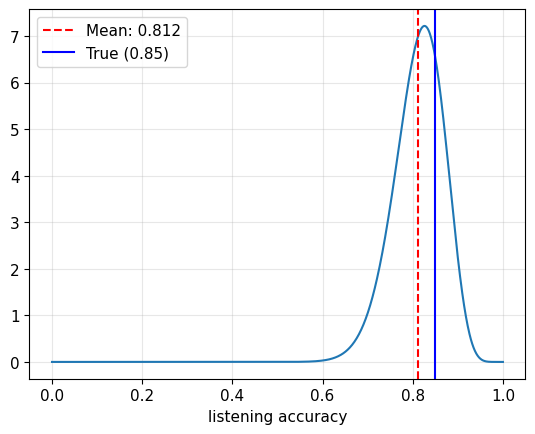

In [ ]:
closed_form_results = closed_form(data)

### Data Preprocessing
This function converts the categorical data in the dataframe into numeric values for easier processing and analysis.

The function preprocess_data maps actions and observations to numeric values. Actions (listen, open-left, open-right) are mapped to 0, 1, and 2 respectively, while observations (tiger-left, tiger-right) are mapped to 0 and 1. This conversion is applied to the appropriate columns in the dataframe, resulting in a new dataframe with numeric values instead of categorical strings. This numeric representation is essential for subsequent modeling and analysis steps.


# Model

## POMDP definition

 **0 - tiger-left, 1 - tiger-right**

 $States$ = {0, 1}

 $\Omega$ = {0, 1}

$Actions$ = {Listen = 0, Open = 1}

 $Observations$ =
* $\text{State = 0, Action = Listen} \Rightarrow p_l, 1-p_l$ -- If we choose to Listen and the State is 0, we will recieve observation 0 (Left) with probability $p_l$ and 1 (Right) with probability $1-p_l$
* $\text{State = 1, Action = Listen} \Rightarrow 1-p_l, p_l$ -- If we choose to Listen and the State is 1, we will recieve observation 0 (Left) with probability $1-p_l$ and 1 (Right) with probability $p_l$
* $\text{State = 0, Action = Open} \Rightarrow 1, 0$ -- If we choose to Open and the State is 0, we will always recieve observation 0 (Left) [probability is 1].
* $\text{State = 1, Action = Open}, \Rightarrow 0, 1$ -- If we choose to Open and the State is 1, we will always recieve observation 1 (Right) [probability is 1].


## Parameter learning

$\epsilon = 0.01$ // Approximate Bayesian computation

$p_0 \sim Beta(1, 1)$ Sampling probability for initial state\
$p_l \sim Beta(1, 1)$ Sampling probability for listen observations

$s \sim Bernoulli(p_0)$ Sampling Initial state (s0)


$\text{for a, o in history:}$
* $\text{if a == listen:}$
    * $\text{if s == 0: (if state is 'tiger-left')}$
        * $o \sim Bernoulli(1-p_l)$
    * $\text{elsif s == 1 (if state is 'tiger-right'):}$
        * $o \sim Bernoulli(p_l)$
* $\text{elsif a == open:}$
    * $\text{if s == 0:}$
        * $o \sim Bernoulli(\epsilon)$
    * $\text{elsif s == 1:}$
        * $o \sim Bernoulli(1-\epsilon)$

In [ ]:
def tiger_model(data):
    p_listen = numpyro.sample("p_listen", dist.Beta(1,1))

    n_episodes = data.shape[0]

    listen_obs_per_episode = []
    true_states = []

    for episode in range(n_episodes):
        actions = data.iloc[episode][[col for col in data.columns if col.startswith('action')]].values
        observations = data.iloc[episode][[col for col in data.columns if col.startswith('obs')]].values

        # Remove NaN and convert to regular numpy
        valid_actions = actions[~np.isnan(actions)]
        valid_obs = observations[~np.isnan(observations)]

        if len(valid_actions) == 0:
            listen_obs_per_episode.append([])
            true_states.append(0)
            continue

        # Determine true state from treasure outcome (last observation)
        final_action = int(valid_actions[-1])
        treasure_outcome = int(valid_obs[-1])

        if final_action == 1:
            true_state = treasure_outcome
        elif final_action == 2:
            true_state = 1 - treasure_outcome
        else:
            listen_obs_per_episode.append([])
            true_states.append(0)
            continue

        true_states.append(true_state)

        # Collect listening observations for this episode
        episode_listen_obs = []
        for i, action in enumerate(valid_actions[:-1]):
            if action == 0 and i < len(valid_obs)-1:
                episode_listen_obs.append(int(valid_obs[i]))
        listen_obs_per_episode.append(episode_listen_obs)

    with numpyro.plate("episodes", n_episodes):
        for episode in range(n_episodes):
            if len(listen_obs_per_episode[episode]) > 0:
                episode_obs = jnp.array(listen_obs_per_episode[episode])
                true_state = true_states[episode]

                # Model the listening accuracy for this episode
                p_correct = jnp.where(episode_obs == true_state, p_listen, 1-p_listen)
                numpyro.sample(f"obs_{episode}",
                             dist.Bernoulli(p_correct).expand([len(episode_obs)]).to_event(1),
                             obs=jnp.ones(len(episode_obs)))

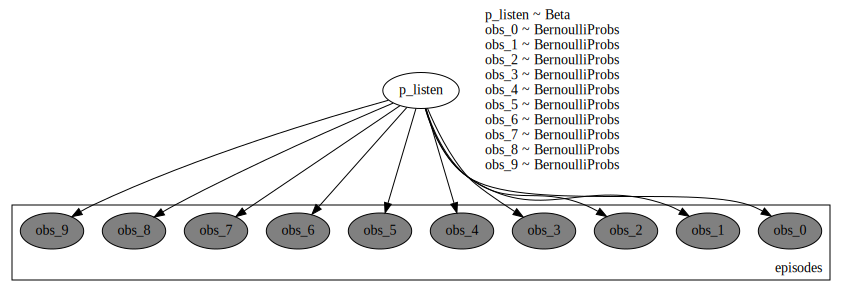

In [ ]:
numpyro.render_model(tiger_model, model_args=(data,), render_distributions=True, render_params=True,)

In [ ]:
def inference(ai_model, data):
    nuts_kernel = numpyro.infer.NUTS(ai_model)
    mcmc = numpyro.infer.MCMC(
        nuts_kernel,
        num_warmup=500,
        num_chains=4,
        num_samples=5000)
    mcmc.run(jax.random.PRNGKey(int(time.time() * 1E6)), data=data)
    mcmc.print_summary()
    return mcmc

In [ ]:
mcmc = inference(tiger_model, data)

  0%|          | 0/5500 [00:00<?, ?it/s]

  0%|          | 0/5500 [00:00<?, ?it/s]

  0%|          | 0/5500 [00:00<?, ?it/s]

  0%|          | 0/5500 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
  p_listen      0.82      0.02      0.82      0.80      0.85   6939.84      1.00

Number of divergences: 0


### Plotting Posterior Samples

This function visualizes the posterior distribution of a parameter by plotting the samples drawn during MCMC inference.

In [ ]:
# Plotting the samples
def plot_samples(mcmc_samples):
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
    for i, (name, samples) in enumerate(mcmc_samples.items()):
        sns.histplot(samples, kde=True, label=name)
        plt.axvline(jnp.mean(samples), color=colors[i % len(colors)], linestyle='--', label=f'Mean: {jnp.mean(samples):.2f}')
        plt.axvline(jnp.median(samples), color=colors[i % len(colors)], linestyle='--', label=f'Median: {jnp.median(samples):.2f}')
        plt.xlabel(name)
        plt.ylabel('Density')
    plt.title(f'Posterior distribution of MCMC samples')
    plt.legend()
    plt.show()

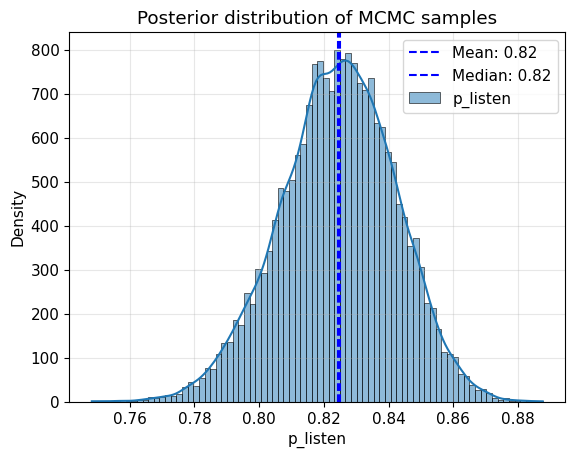

In [ ]:
samples = mcmc.get_samples()
plot_samples(samples)

In [ ]:
def guide(data):
    p_listen_alpha = numpyro.param('p_listen_alpha', 1.0, constraint=dist.constraints.positive)
    p_listen_beta = numpyro.param('p_listen_beta', 1.0, constraint=dist.constraints.positive)

    p_listen = numpyro.sample('p_listen', dist.Beta(p_listen_alpha, p_listen_beta))
    return p_listen

In [ ]:
def logprob_tiger_episode(p_listen, episode_data):
    """Compute episode likelihood by marginalizing over tiger locations"""
    actions, observations = episode_data

    # Initialize log probabilities for both tiger locations
    tiger_left_logp = 0.0   # tiger at location 0
    tiger_right_logp = 0.0  # tiger at location 1

    # Process each observation for both tiger locations
    for i, action in enumerate(actions):
        if action == 0:  # listen action
            heard_location = observations[i]  # 0=left, 1=right

            if heard_location == 0:  # heard left
                tiger_left_logp += jnp.log(p_listen)      # correct if tiger left
                tiger_right_logp += jnp.log(1 - p_listen) # incorrect if tiger right
            else:  # heard right
                tiger_left_logp += jnp.log(1 - p_listen)  # incorrect if tiger left
                tiger_right_logp += jnp.log(p_listen)     # correct if tiger right

        elif action in [1, 2]:  # open action
            door_choice = 0 if action == 1 else 1
            treasure_outcome = observations[i]

            # For tiger left (location 0)
            got_treasure_left = jnp.where(0 != door_choice, 1, 0)
            p_left = jnp.where(treasure_outcome == got_treasure_left, 0.99, 0.01)
            tiger_left_logp += jnp.log(p_left)

            # For tiger right (location 1)
            got_treasure_right = jnp.where(1 != door_choice, 1, 0)
            p_right = jnp.where(treasure_outcome == got_treasure_right, 0.99, 0.01)
            tiger_right_logp += jnp.log(p_right)

    # Marginalize over tiger locations with uniform prior
    total_logp = jnp.logaddexp(
        tiger_left_logp + jnp.log(0.5),
        tiger_right_logp + jnp.log(0.5))

    return total_logp

def tiger_model_svi(data):
    p_listen = numpyro.sample("p_listen", dist.Beta(1,1))

    for episode in range(data.shape[0]):
        # Get episode data
        actions = data.iloc[episode][[col for col in data.columns if col.startswith('action')]].values
        observations = data.iloc[episode][[col for col in data.columns if col.startswith('obs')]].values

        valid_actions = actions[~np.isnan(actions)]
        valid_obs = observations[~np.isnan(observations)]

        if len(valid_actions) == 0:
            continue

        episode_data = (valid_actions, valid_obs)

        episode_logp = logprob_tiger_episode(p_listen, episode_data)
        numpyro.factor(f'episode-{episode}', episode_logp)

In [ ]:
def svi_inference(model, guide, data, num_steps=500):
    print("Running SVI inference...")

    optimizer = numpyro.optim.Adam(step_size=0.01)
    svi = SVI(model, guide, optimizer,
              loss=Trace_ELBO(num_particles=1000))

    rng_key = jax.random.PRNGKey(int(time.time() * 1E6))

    # init
    svi_state = svi.init(rng_key, data)

    losses0 = jnp.zeros(num_steps)
    means0  = jnp.zeros(num_steps)
    sds0    = jnp.zeros(num_steps)

    def body_fn(i, carry):
        svi_state, losses, means, sds = carry

        svi_state, loss = svi.update(svi_state, data)

        params = svi.get_params(svi_state)
        alpha = params['p_listen_alpha']
        beta = params['p_listen_beta']
        mean_val = alpha / (alpha + beta)

        losses = losses.at[i].set(loss)
        means  = means.at[i].set(mean_val)

        return svi_state, losses, means, sds

    svi_state, losses, means, sds = jax.lax.fori_loop(
        0, num_steps, body_fn, (svi_state, losses0, means0, sds0)
    )

    params = svi.get_params(svi_state)
    return list(np.array(losses)), list(np.array(means)), params

In [ ]:
losses, means, final_params = svi_inference(tiger_model_svi, guide, data, num_steps=2000)

Running SVI inference...


In [ ]:
def plot_svi_inference(losses, means, final_params=None, closed_form_results=None, true_p_listen=0.85):
    from scipy import stats

    fig, ax = plt.subplots(2, 1)

    # Plot mean p_listen
    ax[0].plot(means)
    ax[0].axhline(y=true_p_listen, ls='dashed', color='red', label=f'True p_listen ({true_p_listen})')
    ax[0].set_xlabel("Step")
    ax[0].set_ylabel("Mean p_listen")
    ax[0].set_title("Learned Listening Accuracy")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Plot posterior comparison
    if final_params is not None:
        alpha_svi = final_params['p_listen_alpha'].item()
        beta_svi = final_params['p_listen_beta'].item()

        p_grid = np.linspace(0, 1, 1000)
        svi_posterior = stats.beta(alpha_svi, beta_svi).pdf(p_grid)
        svi_mean = alpha_svi / (alpha_svi + beta_svi)

        ax[1].plot(p_grid, svi_posterior, '-', linewidth=3, label=f'SVI', color='blue')

        # Add closed form posterior if available
        if closed_form_results is not None:
            alpha_cf = closed_form_results['alpha']
            beta_cf = closed_form_results['beta']
            cf_posterior = stats.beta(alpha_cf, beta_cf).pdf(p_grid)
            ax[1].plot(p_grid, cf_posterior, '--', linewidth=3, label=f'Closed Form', color='green')

        ax[1].axvline(true_p_listen, color='red', linestyle=':', label=f'True ({true_p_listen})')
        ax[1].axvline(means[-1], linestyle=':', label=f'Inferred Mean ({means[-1]:.2f})')

        ax[1].set_xlabel("Listening Accuracy")
        ax[1].set_ylabel("Posterior Density")
        ax[1].set_title("Posterior Comparison")
        ax[1].legend()
        ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print comparison
    print(f"\nSVI: Mean={means[-1]:.3f}")
    if closed_form_results is not None:
        print(f"Closed Form: Mean={closed_form_results['mean']:.3f}")
    print(f"True: {true_p_listen}")

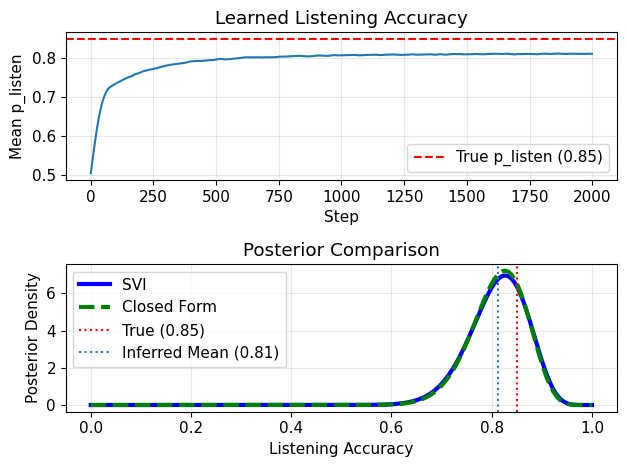


SVI: Mean=0.812
Closed Form: Mean=0.812
True: 0.85


In [ ]:
plot_svi_inference(losses, means, final_params, closed_form_results, true_p_listen=0.85)

In [ ]:
def plot_svi_convergence(losses, means, closed_form_results=None, true_value=None,
                         param_label=r"$p_{\text{listen}}$"):
    """
    Convergence figure with consistent colors and professional styling.
    Colors: SVI Loss=black, SVI mean=steelblue, Closed-form=orange, True=red.
    """
    loss_arr = np.asarray(losses, dtype=float)
    mean_arr = np.asarray(means,  dtype=float)

    # Professional styling
    plt.style.use('default')
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 6))

    # Top: ELBO with BLACK styling (no final annotation)
    ax0.plot(loss_arr, color="black", lw=1.5, alpha=0.8)
    ax0.set_title("SVI Loss Convergence (ELBO)", fontsize=13, pad=15)
    ax0.set_xlabel("Iteration", fontsize=11)
    ax0.set_ylabel("Loss", fontsize=11)
    ax0.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # Bottom: mean trace with consistent colors
    ax1.plot(mean_arr, color="steelblue", lw=2, alpha=0.9, label="SVI posterior mean")

    if isinstance(closed_form_results, dict) and ("mean" in closed_form_results):
        cf_mean = float(closed_form_results["mean"])
        ax1.axhline(cf_mean, color="orange", linestyle="--", lw=2,
                    label=f"Analytical mean: {cf_mean:.3f}")

    if true_value is not None:
        ax1.axhline(float(true_value), color="red", linestyle="-", lw=2.5, alpha=0.9,
                    label=f"Simulation value: {true_value}")

    # Position text just BELOW final mean value
    if len(mean_arr) > 0:
        final_mean = mean_arr[-1]
        final_iteration = len(mean_arr) - 1

        # Calculate offset as 3% of the y-range (negative for below)
        y_range = ax1.get_ylim()[1] - ax1.get_ylim()[0]
        y_offset = y_range * -0.03  # Negative for below

        ax1.text(final_iteration, final_mean + y_offset,
                f'Final SVI: {final_mean:.3f}',
                ha='right', va='top', fontsize=9, alpha=0.7)  # va='top' for below

    ax1.set_title(f"Parameter Convergence: {param_label}", fontsize=13, pad=15)
    ax1.set_xlabel("Iteration", fontsize=11)
    ax1.set_ylabel("Posterior mean", fontsize=11)
    ax1.legend(loc="best", framealpha=0.95, fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, (ax0, ax1)


def plot_posterior_comparison(final_params, means, closed_form_results=None, true_value=None,
                            param_label=r"$p_{\text{listen}}$", num_samples=40000):
    # Extract SVI posterior parameters
    alpha_svi = float(np.asarray(final_params["p_listen_alpha"]))
    beta_svi = float(np.asarray(final_params["p_listen_beta"]))
    svi_samples = np.random.beta(alpha_svi, beta_svi, int(num_samples))

    # Extract closed-form posterior (if available)
    cf_samples = None
    if isinstance(closed_form_results, dict) and all(k in closed_form_results for k in ("alpha", "beta")):
        alpha_cf = float(closed_form_results["alpha"])
        beta_cf = float(closed_form_results["beta"])
        cf_samples = np.random.beta(alpha_cf, beta_cf, int(num_samples))

    # Professional styling
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create x-axis for density curves
    all_samples = svi_samples
    if cf_samples is not None:
        all_samples = np.concatenate([svi_samples, cf_samples])
    x_min = all_samples.min() - 0.05
    x_max = all_samples.max() + 0.05
    x = np.linspace(x_min, x_max, 200)

    # Compute and plot density curves
    svi_kde = stats.gaussian_kde(svi_samples)
    svi_density = svi_kde(x)
    ax.fill_between(x, svi_density, alpha=0.3, color='steelblue', label='SVI posterior')
    ax.plot(x, svi_density, color='steelblue', linewidth=2)

    if cf_samples is not None:
        cf_mean = np.mean(cf_samples)
        cf_kde = stats.gaussian_kde(cf_samples)
        cf_density = cf_kde(x)
        ax.fill_between(x, cf_density, alpha=0.3, color='orange', label=f'Analytical mean: {cf_mean:.3f}')
        ax.plot(x, cf_density, color='orange', linewidth=2)

    # Add vertical lines and credible intervals
    svi_mean = float(means[-1])
    svi_ci = np.percentile(svi_samples, [2.5, 97.5])

    ax.axvline(svi_mean, color='steelblue', linestyle='--', linewidth=2,
               alpha=0.8, label=f'SVI mean: {svi_mean:.3f}')
    ax.axvspan(svi_ci[0], svi_ci[1], alpha=0.1, color='steelblue',
            label=f'SVI 95% CI: [{svi_ci[0]:.2f}, {svi_ci[1]:.2f}]')

    if cf_samples is not None:
        cf_mean = np.mean(cf_samples)
        cf_ci = np.percentile(cf_samples, [2.5, 97.5])
        ax.axvline(cf_mean, color='orange', linestyle='--', linewidth=2, alpha=0.8)
        ax.axvspan(cf_ci[0], cf_ci[1], alpha=0.1, color='orange',
            label=f'Closed Form 95% CI: [{cf_ci[0]:.2f}, {cf_ci[1]:.2f}]')

    # Add Simulation value line
    if true_value is not None:
        ax.axvline(float(true_value), color='red', linestyle='-', linewidth=2.5,
                   alpha=0.9, label=f'Simulation value: {true_value}')

    # Professional styling
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Posterior density', fontsize=12)
    ax.set_title(f'Posterior Inference Results: {param_label}', fontsize=13, pad=20)
    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set axis limits with padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.show()

    # Enhanced numerical summary
    print("\n" + "="*60)
    print("POSTERIOR INFERENCE SUMMARY")
    print("="*60)
    print(f"{'Method':<12} {'Mean':<8} {'Std':<8} {'95% CI':<20} {'Mode':<8}")
    print("-" * 60)

    # SVI statistics
    svi_mode = x[np.argmax(svi_density)]  # Approximate mode
    print(f"{'SVI':<12} {svi_mean:<8.3f} {np.std(svi_samples):<8.3f} "
          f"[{svi_ci[0]:.3f}, {svi_ci[1]:.3f}] {svi_mode:<8.3f}")

    if cf_samples is not None:
        cf_mode = x[np.argmax(cf_density)]
        print(f"{'Analytical':<12} {cf_mean:<8.3f} {np.std(cf_samples):<8.3f} "
              f"[{cf_ci[0]:.3f}, {cf_ci[1]:.3f}] {cf_mode:<8.3f}")

        # Quality metrics
        mean_diff = abs(svi_mean - cf_mean)
        print(f"\nMethod Comparison:")
        print(f"  Mean difference: {mean_diff:.4f}")
        print(f"  Relative error:  {(mean_diff/cf_mean*100):.2f}%")

        # Overlap coefficient (area under both curves)
        overlap = np.trapz(np.minimum(svi_density, cf_density), x)
        print(f"  Distribution overlap: {overlap:.3f}")

    if true_value is not None:
        true_val = float(true_value)
        svi_error = abs(svi_mean - true_val)
        print(f"\Simulation Value Comparison:")
        print(f"  Simulation value: {true_val:.3f}")
        print(f"  SVI error:  {svi_error:.4f}")

    print("="*60)

    return fig, ax

<>:167: SyntaxWarning: invalid escape sequence '\S'
<>:167: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-3687254179.py:167: SyntaxWarning: invalid escape sequence '\S'
  print(f"\Simulation Value Comparison:")


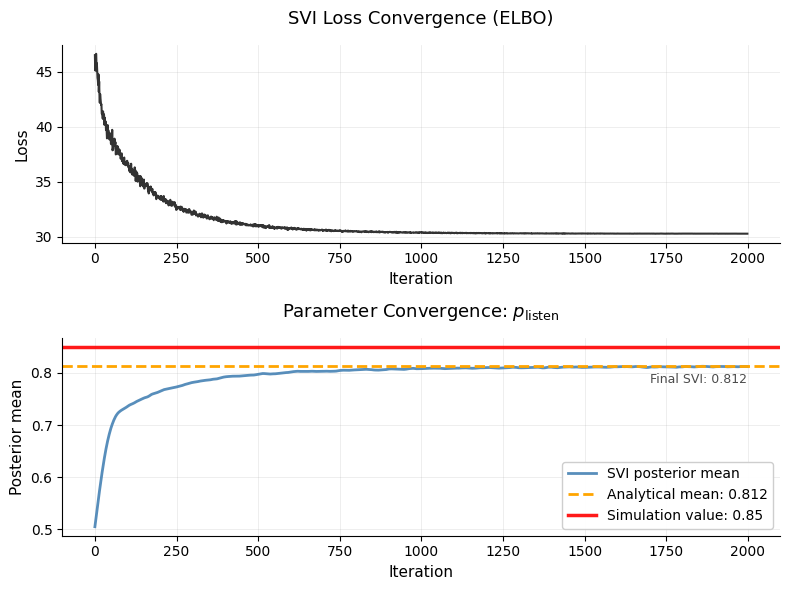

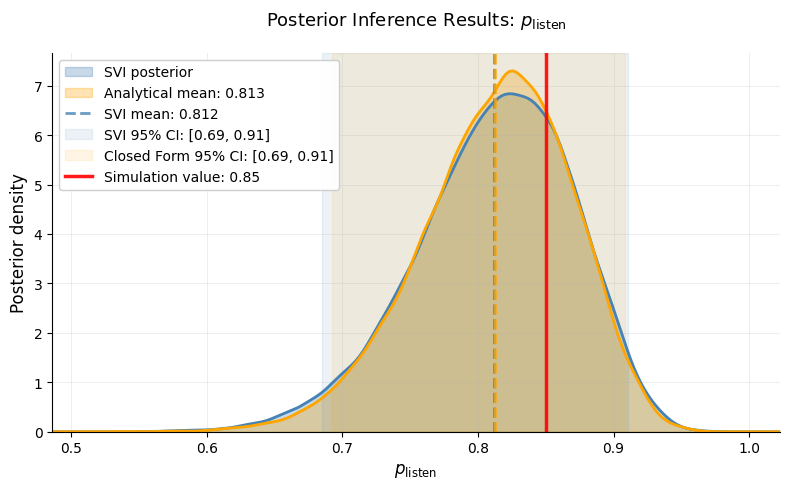


POSTERIOR INFERENCE SUMMARY
Method       Mean     Std      95% CI               Mode    
------------------------------------------------------------
SVI          0.812    0.058    [0.685, 0.910] 0.823   
Analytical   0.813    0.056    [0.692, 0.909] 0.826   

Method Comparison:
  Mean difference: 0.0006
  Relative error:  0.07%
  Distribution overlap: 0.980
\Simulation Value Comparison:
  Simulation value: 0.850
  SVI error:  0.0380


/tmp/ipython-input-3687254179.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.minimum(svi_density, cf_density), x)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Inference Results: $p_{\\text{listen}}$'}, xlabel='$p_{\\text{listen}}$', ylabel='Posterior density'>)

In [ ]:
plot_svi_convergence(
    losses, means,
    closed_form_results=closed_form_results,
    true_value=0.85,
    param_label=r"$p_{\text{listen}}$"
)

plot_posterior_comparison(
    final_params, means,
    closed_form_results=closed_form_results,
    true_value=0.85,
    param_label=r"$p_{\text{listen}}$",
)

In [ ]:
def benchmark_tiger_svi(svi_inference_func, model, guide, data, num_steps=2000, num_runs=10):

    print(f"\nBenchmarking Tiger POMDP SVI Inference...")
    print(f"Configuration: {num_steps} iterations, {num_runs} independent runs")
    print(f"Running timing benchmark...")
    print("-" * 40)

    times = []

    for run in range(num_runs):
        print(f"Run {run+1:2d}/{num_runs}: ", end="", flush=True)

        # Clear JAX caches for consistent timing
        jax.clear_caches()

        # Time the inference
        start_time = time.time()

        # Call your SVI inference function with correct argument order
        losses, means, final_params = svi_inference_func(model, guide, data, num_steps)

        end_time = time.time()

        run_time = end_time - start_time
        times.append(run_time)

        print(f"{run_time:6.2f}s")

    times = np.array(times)

    # Calculate statistics
    stats = {
        'mean': np.mean(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
        'median': np.median(times),
        'times': times,
        'num_steps': num_steps,
        'num_runs': num_runs
    }

    # Print results
    print("-" * 40)
    print("TIGER POMDP TIMING RESULTS")
    print("-" * 40)
    print(f"Mean ± Std:  {stats['mean']:6.2f} ± {stats['std']:5.2f} seconds")
    print(f"Median:      {stats['median']:6.2f} seconds")
    print(f"Range:       [{stats['min']:5.2f}, {stats['max']:5.2f}] seconds")
    print(f"Per iteration: {stats['mean']/num_steps*1000:5.1f} ms/iteration")
    print("-" * 40)

    return stats

def plot_timing_results(stats):
    """Plot timing results for analysis."""
    import matplotlib.pyplot as plt

    times = stats['times']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    ax1.boxplot([times], labels=['Tiger SVI'])
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('Timing Distribution')
    ax1.grid(True, alpha=0.3)

    # Time series
    ax2.plot(range(1, len(times)+1), times, 'o-', alpha=0.7)
    ax2.axhline(np.mean(times), color='red', linestyle='--',
                label=f'Mean: {np.mean(times):.2f}s')
    ax2.fill_between(range(1, len(times)+1),
                     np.mean(times) - np.std(times),
                     np.mean(times) + np.std(times),
                     alpha=0.2, color='red')
    ax2.set_xlabel('Run Number')
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Timing Across Runs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
tiger_stats = benchmark_tiger_svi(
    svi_inference_func=svi_inference,
    data=data,
    model=tiger_model_svi,
    guide=guide,
    num_steps=2000,
    num_runs=10
)

plot_timing_results(tiger_stats)